# 📖 Notebook 3: Distributed Top-K

In Notebooks 1 and 2, we built Count-Min Sketch and a Heap-based Top-K — both running on a **single machine**. But YouTube processes ~700K view events per second. No single machine can handle that.

In this notebook, we'll explore the patterns used to distribute Top-K across multiple machines:
- **Sharding** — split the work across partitions
- **Tumbling windows** — aggregate counts into time buckets
- **Redis sorted sets** — a shared data structure for real-time leaderboards
- **Precomputation + caching** — compute once, serve many times

## Learning Objectives

By the end of this notebook, you'll understand:
- Why a single machine can't handle YouTube-scale view counting
- How sharding splits the work and how to merge partial top-K results
- What tumbling windows are and how they simplify time-based queries
- How Redis sorted sets work as a real-time leaderboard
- How precomputation + caching makes queries fast

## 🛠️ Setup

Start the infrastructure first:

```bash
cd system-designs/top-k
docker-compose up -d
```

### Visualization Tools

- **Adminer** (PostgreSQL GUI): http://localhost:8080  
  Login: System `PostgreSQL`, Server `postgres`, User `demo`, Password `demo`, Database `topk_demo`
- **RedisInsight** (Redis GUI): http://localhost:5540  
  Click "Add Redis Database" → Host `redis`, Port `6379`

### Kernel Selection

Select the `.venv` kernel in VS Code's kernel picker (top-right of notebook).  
If it doesn't appear, reload the window: `Cmd+Shift+P` → "Reload Window".

In [1]:
import psycopg2
import redis
import time
import json
import heapq
import hashlib
import random
from datetime import datetime, timedelta
from collections import defaultdict

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "topk_demo",
    "user": "demo",
    "password": "demo"
}

REDIS_CONFIG = {
    "host": "localhost",
    "port": 6379,
    "decode_responses": True
}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG)

def get_redis_client():
    return redis.Redis(**REDIS_CONFIG)

# Test connections
try:
    conn = get_db_connection()
    conn.close()
    print("✅ Connected to PostgreSQL")
except Exception as e:
    print(f"❌ PostgreSQL failed: {e}")

try:
    r = get_redis_client()
    r.ping()
    print("✅ Connected to Redis")
except Exception as e:
    print(f"❌ Redis failed: {e}")

✅ Connected to PostgreSQL
✅ Connected to Redis


## 🤔 Why One Machine Isn't Enough

Let's do some quick math to understand the scale:

- YouTube: ~70 billion views/day = ~700K views/second
- A single PostgreSQL can handle ~10K writes/second under ideal conditions
- 700K / 10K = **70 database instances** just for writes!

And that's just counting. We also need to:
- Store view events (or at least hourly aggregates)
- Query the top K across ALL videos for different time windows
- Serve results in <50ms to users

We need to **split the work** across multiple machines.

In [2]:
print("📊 Scale Estimation: YouTube Top-K")
print("=" * 55)
print()

views_per_day = 70_000_000_000
seconds_per_day = 100_000  # rounded for easy math (actual: 86,400)
views_per_second = views_per_day // seconds_per_day

print(f"  Views per day:     {views_per_day:>15,}")
print(f"  Views per second:  {views_per_second:>15,}")
print()

# Storage estimation
videos_per_day = 1_000_000  # ~1 hour of content uploaded per second
total_videos = videos_per_day * 365 * 10  # 10 years
bytes_per_entry = 16  # 8 bytes video_id + 8 bytes count
naive_storage_gb = total_videos * bytes_per_entry / (1024**3)

print(f"  Total videos (10yr): {total_videos:>13,}")
print(f"  Naive storage:       {naive_storage_gb:>13.0f} GB")
print()

# Sharding needs
db_writes_per_sec = 10_000
shards_needed = views_per_second // db_writes_per_sec
print(f"  DB capacity:         {db_writes_per_sec:>13,} writes/sec")
print(f"  Shards needed:       {shards_needed:>13,}")
print()
print("💡 We need ~70 DB shards just for writes — and that's BEFORE")
print("   considering that window queries scan millions of rows!")

📊 Scale Estimation: YouTube Top-K

  Views per day:      70,000,000,000
  Views per second:          700,000

  Total videos (10yr): 3,650,000,000
  Naive storage:                  54 GB

  DB capacity:                10,000 writes/sec
  Shards needed:                  70

💡 We need ~70 DB shards just for writes — and that's BEFORE
   considering that window queries scan millions of rows!


## 🔀 Pattern 1: Sharding

**Sharding** splits data across multiple machines based on a key (video ID).  
Each shard handles a subset of videos independently.

```
  View Events (Kafka, partitioned by video_id)
  ┌──────────┬──────────┬──────────┐
  │ Shard 0  │ Shard 1  │ Shard 2  │
  │ vid_000  │ vid_001  │ vid_002  │
  │ vid_003  │ vid_004  │ vid_005  │
  │ vid_006  │ vid_007  │ vid_008  │
  │   ...    │   ...    │   ...    │
  └────┬─────┴────┬─────┴────┬─────┘
       │          │          │
       ▼          ▼          ▼
  ┌─────────┐┌─────────┐┌─────────┐
  │  DB 0   ││  DB 1   ││  DB 2   │
  └────┬────┘└────┬────┘└────┬────┘
       │          │          │
       └──────────┼──────────┘
                  │
            ┌─────▼─────┐
            │  MERGE    │  ← Get top K from each shard,
            │  Top-K    │    merge into global top K
            └───────────┘
```

**The key insight**: if you get the top K from EACH shard, the global top K  
is guaranteed to be somewhere in the union of those partial results.

In [3]:
# Load view events from DB
conn = get_db_connection()
cursor = conn.cursor()
cursor.execute("SELECT video_id, viewed_at FROM view_events ORDER BY viewed_at")
all_events = cursor.fetchall()
conn.close()

print(f"📦 Loaded {len(all_events):,} view events")
print()

# Simulate sharding: assign each video to a shard based on hash
NUM_SHARDS = 3

def get_shard(video_id: str, num_shards: int) -> int:
    """Determine which shard a video belongs to using consistent hashing."""
    hash_val = int(hashlib.md5(video_id.encode()).hexdigest(), 16)
    return hash_val % num_shards

# Split events into shards
shard_counts = [defaultdict(int) for _ in range(NUM_SHARDS)]
for video_id, viewed_at in all_events:
    shard = get_shard(video_id, NUM_SHARDS)
    shard_counts[shard][video_id] += 1

for i in range(NUM_SHARDS):
    total = sum(shard_counts[i].values())
    print(f"  Shard {i}: {len(shard_counts[i]):>3} videos, {total:>6,} events")

print()
print("💡 Each shard only handles a subset of videos.")
print("   This spreads the write load across multiple databases.")

📦 Loaded 488 view events

  Shard 0:  14 videos,    156 events
  Shard 1:  18 videos,    204 events
  Shard 2:  18 videos,    128 events

💡 Each shard only handles a subset of videos.
   This spreads the write load across multiple databases.


In [4]:
# Merge: get top K from each shard, then merge
K = 10

print(f"🔀 Shard-Local Top-{K} → Merge → Global Top-{K}")
print("=" * 60)

# Step 1: Get top K from each shard
shard_top_k = []
for i in range(NUM_SHARDS):
    local_top = sorted(
        shard_counts[i].items(), key=lambda x: x[1], reverse=True
    )[:K]
    shard_top_k.append(local_top)
    
    print(f"\n  Shard {i} top {K}:")
    for rank, (vid, count) in enumerate(local_top[:5], 1):
        print(f"    {rank}. {vid}: {count:,} views")
    if len(local_top) > 5:
        print(f"    ... and {len(local_top) - 5} more")

# Step 2: Merge all shard results and take global top K
all_candidates = []
for local_top in shard_top_k:
    all_candidates.extend(local_top)

global_top_k = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:K]

print(f"\n🏆 Global Top {K} (merged from {NUM_SHARDS} shards):")
print(f"  {'Rank':<6} {'Video ID':<12} {'Views':>8}")
print("  " + "-" * 28)
for rank, (vid, count) in enumerate(global_top_k, 1):
    print(f"  {rank:<6} {vid:<12} {count:>8,}")

print()
print("✅ Merging shard-local top-K results gives the correct global top-K.")
print("   Each shard runs its query independently → easy to parallelize!")

🔀 Shard-Local Top-10 → Merge → Global Top-10

  Shard 0 top 10:
    1. vid_021: 45 views
    2. vid_003: 40 views
    3. vid_036: 35 views
    4. vid_009: 5 views
    5. vid_006: 5 views
    ... and 5 more

  Shard 1 top 10:
    1. vid_010: 80 views
    2. vid_001: 50 views
    3. vid_002: 25 views
    4. vid_029: 15 views
    5. vid_019: 4 views
    ... and 5 more

  Shard 2 top 10:
    1. vid_007: 25 views
    2. vid_032: 25 views
    3. vid_042: 15 views
    4. vid_011: 15 views
    5. vid_015: 15 views
    ... and 5 more

🏆 Global Top 10 (merged from 3 shards):
  Rank   Video ID        Views
  ----------------------------
  1      vid_010            80
  2      vid_001            50
  3      vid_021            45
  4      vid_003            40
  5      vid_036            35
  6      vid_002            25
  7      vid_007            25
  8      vid_032            25
  9      vid_029            15
  10     vid_042            15

✅ Merging shard-local top-K results gives the correct g

## ⏰ Pattern 2: Tumbling Windows

For time-based queries ("top videos in the last hour"), we need to organize events by time.

**Tumbling windows** divide time into fixed, non-overlapping buckets:

```
  Time: 9:00    10:00    11:00    12:00    13:00
        |--------|--------|--------|--------|
        Window 1  Window 2  Window 3  Window 4
        
  Each window is independent. No overlap.
  "Last hour" at 13:06 = Window 4 (13:00–14:00)
```

This is simpler than **sliding windows** (where "last hour" at 13:06 = 12:06–13:06)  
and is what our `hourly_views` table already uses.

In [5]:
# Demonstrate tumbling windows using our view events

def truncate_to_hour(dt):
    """Truncate a datetime to the start of its hour (tumbling window)."""
    return dt.replace(minute=0, second=0, microsecond=0)

# Group events into hourly windows
hourly_windows = defaultdict(lambda: defaultdict(int))

for video_id, viewed_at in all_events:
    hour_bucket = truncate_to_hour(viewed_at)
    hourly_windows[hour_bucket][video_id] += 1

# Sort windows by time
sorted_windows = sorted(hourly_windows.keys())

print(f"⏰ Tumbling Windows: {len(sorted_windows)} hourly buckets")
print("=" * 60)

# Show a few windows
for window in sorted_windows[:5]:
    counts = hourly_windows[window]
    total_events = sum(counts.values())
    top_vid = max(counts.items(), key=lambda x: x[1])
    print(f"  {window.strftime('%Y-%m-%d %H:00')} │ {total_events:>5} events │"
          f" {len(counts):>3} videos │ top: {top_vid[0]} ({top_vid[1]})")

if len(sorted_windows) > 5:
    print(f"  ... ({len(sorted_windows) - 5} more windows)")

print()
print("💡 Each window can be processed independently.")
print("   To get 'last 24 hours': sum the last 24 windows.")
print("   To get 'last month': sum the last ~720 windows.")

⏰ Tumbling Windows: 49 hourly buckets
  2026-04-18 03:00 │     4 events │   3 videos │ top: vid_036 (2)
  2026-04-18 04:00 │    12 events │   8 videos │ top: vid_010 (3)
  2026-04-18 05:00 │    15 events │   8 videos │ top: vid_010 (5)
  2026-04-18 06:00 │    18 events │  12 videos │ top: vid_001 (4)
  2026-04-18 07:00 │     7 events │   5 videos │ top: vid_010 (3)
  ... (44 more windows)

💡 Each window can be processed independently.
   To get 'last 24 hours': sum the last 24 windows.
   To get 'last month': sum the last ~720 windows.


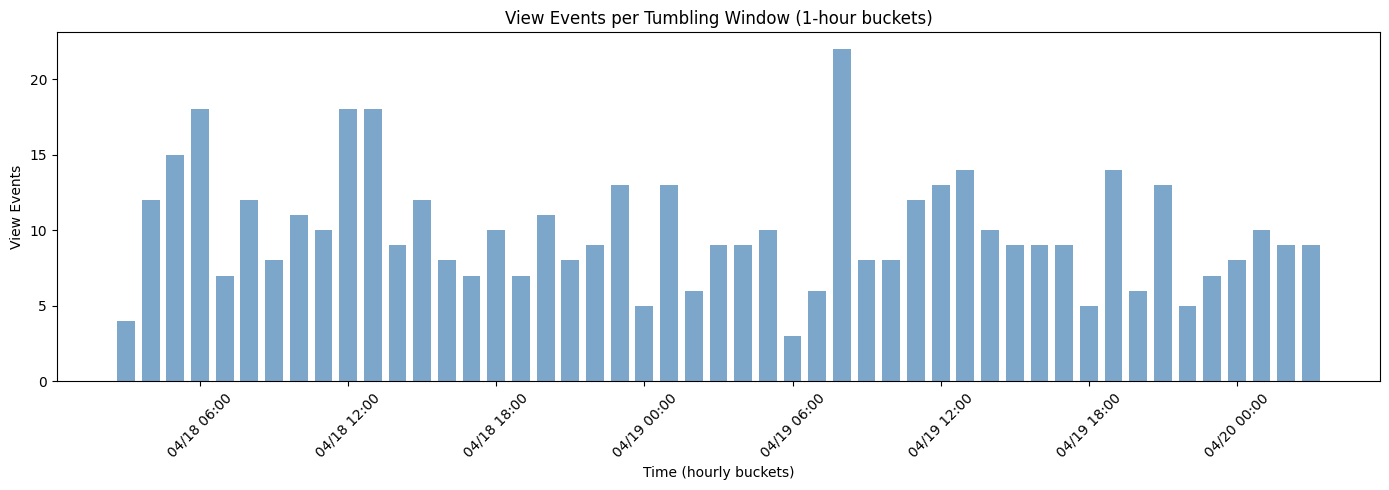

💡 Each bar is one tumbling window (1 hour).
   Events are fairly evenly distributed because our seed data
   uses random timestamps within the last 48 hours.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Visualize the tumbling windows
fig, ax = plt.subplots(figsize=(14, 5))

window_times = sorted_windows
window_totals = [sum(hourly_windows[w].values()) for w in window_times]

ax.bar(window_times, window_totals, width=0.03, color='steelblue', alpha=0.7)
ax.set_xlabel('Time (hourly buckets)')
ax.set_ylabel('View Events')
ax.set_title('View Events per Tumbling Window (1-hour buckets)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %H:00'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("💡 Each bar is one tumbling window (1 hour).")
print("   Events are fairly evenly distributed because our seed data")
print("   uses random timestamps within the last 48 hours.")

### ⏳ Tumbling vs. Sliding Windows

A **tumbling window** snaps to fixed boundaries (e.g., 12:00–13:00, 13:00–14:00).
A **sliding window** moves continuously with the current time (e.g., "the last
60 minutes from right now").

* ✅ Tumbling is cheap — every event belongs to exactly one bucket, and the
  bucket is fully done once its hour ends.
* ⚠️ Sliding is more accurate for "latest N minutes" queries but requires
  keeping raw events (or many tiny buckets) so you can re-sum on every query.

A common **compromise** in production: use **small tumbling buckets** (e.g.,
1-minute) and sum the most recent N of them to *approximate* a sliding window.
Let's show this trade-off directly on our data.


In [7]:
from datetime import datetime, timedelta

# Pick a reference "now" that sits inside our data
now_ref = max(e[1] for e in all_events)

# ---- Tumbling: "this hour" = the bucket containing now_ref ----
tumbling_bucket = truncate_to_hour(now_ref)
tumbling_counts = hourly_windows[tumbling_bucket]

# ---- Sliding: "last 60 minutes up to now_ref" ----
sliding_cutoff = now_ref - timedelta(minutes=60)
sliding_counts = defaultdict(int)
for vid, viewed_at in all_events:
    if viewed_at > sliding_cutoff and viewed_at <= now_ref:
        sliding_counts[vid] += 1

def top_k(counts, k=5):
    return sorted(counts.items(), key=lambda x: x[1], reverse=True)[:k]

print(f"Reference 'now': {now_ref}")
print()
print(f"📊 Tumbling bucket {tumbling_bucket.strftime('%H:00')}–{(tumbling_bucket+timedelta(hours=1)).strftime('%H:00')}: "
      f"{sum(tumbling_counts.values())} events, {len(tumbling_counts)} videos")
for vid, c in top_k(tumbling_counts):
    print(f"   {vid}: {c}")
print()
print(f"📊 Sliding window {sliding_cutoff.strftime('%H:%M')}–{now_ref.strftime('%H:%M')} "
      f"(exactly 60 min): {sum(sliding_counts.values())} events, {len(sliding_counts)} videos")
for vid, c in top_k(sliding_counts):
    print(f"   {vid}: {c}")
print()
print("💡 The two answers can differ! The tumbling bucket only covers the")
print("   minutes since the top of the hour, so it undercounts if 'now' is")
print("   early in the hour. Sliding is exact but costs more to compute.")


Reference 'now': 2026-04-20 03:32:54.333596

📊 Tumbling bucket 03:00–04:00: 9 events, 8 videos
   vid_010: 2
   vid_034: 1
   vid_017: 1
   vid_032: 1
   vid_001: 1

📊 Sliding window 02:32–03:32 (exactly 60 min): 13 events, 9 videos
   vid_001: 2
   vid_021: 2
   vid_003: 2
   vid_010: 2
   vid_002: 1

💡 The two answers can differ! The tumbling bucket only covers the
   minutes since the top of the hour, so it undercounts if 'now' is
   early in the hour. Sliding is exact but costs more to compute.


## 🔴 Pattern 3: Redis Sorted Sets

Redis **sorted sets** (ZSET) are a perfect fit for leaderboards and top-K:
- Each member has a **score** (the view count)
- Members are always sorted by score
- Getting the top K is O(K + log N) — very fast!

In the distributed pipeline, Redis acts as the **shared cache** that all servers read from:

```
  View Consumers          PostgreSQL Shards         Redis
  ┌──────────┐           ┌──────────┐            ┌──────────────┐
  │ Consume  │──write──▶│  Count   │            │  ZSET:       │
  │ events   │           │  views   │            │  top-k:hour  │
  └──────────┘           └────┬─────┘            │  top-k:day   │
                              │                  │  top-k:all   │
                         ┌────▼─────┐            └──────▲───────┘
                         │ Top-K    │──precompute──────┘
                         │ Cron Job │
                         └──────────┘
```

In [8]:
r = get_redis_client()

# Clean up any previous run
for key in r.keys("notebook3:*"):
    r.delete(key)

# Demonstrate Redis Sorted Sets for top-K
print("🔴 Redis Sorted Sets (ZSET) Basics")
print("=" * 50)

# ZADD: add members with scores
zset_key = "notebook3:demo_leaderboard"
r.zadd(zset_key, {
    "vid_010": 4000,
    "vid_001": 2500,
    "vid_021": 2250,
    "vid_003": 2000,
    "vid_036": 1750,
    "vid_007": 1250,
})

print("\n  Added 6 videos with view counts to a sorted set.")
print()

# ZREVRANGE: get top K (highest scores first)
top3 = r.zrevrange(zset_key, 0, 2, withscores=True)
print("  ZREVRANGE (top 3):")
for rank, (vid, score) in enumerate(top3, 1):
    print(f"    {rank}. {vid}: {int(score):,} views")
print()

# ZINCRBY: atomically increment a score
r.zincrby(zset_key, 500, "vid_001")  # vid_001: 2500 + 500 = 3000
print("  ZINCRBY vid_001 +500 → ", int(r.zscore(zset_key, "vid_001")))
print()

# ZREVRANK: what rank is a specific video?
rank = r.zrevrank(zset_key, "vid_003")
print(f"  ZREVRANK vid_003 → rank {rank} (0-indexed)")
print()

# ZCARD: how many members?
print(f"  ZCARD → {r.zcard(zset_key)} members")
print()
print("💡 All operations are O(log N) — fast even with millions of members.")
print("   ZREVRANGE for top K is O(K + log N) — perfect for leaderboards!")

🔴 Redis Sorted Sets (ZSET) Basics

  Added 6 videos with view counts to a sorted set.

  ZREVRANGE (top 3):
    1. vid_010: 4,000 views
    2. vid_001: 2,500 views
    3. vid_021: 2,250 views

  ZINCRBY vid_001 +500 →  3000

  ZREVRANK vid_003 → rank 3 (0-indexed)

  ZCARD → 6 members

💡 All operations are O(log N) — fast even with millions of members.
   ZREVRANGE for top K is O(K + log N) — perfect for leaderboards!


In [9]:
# Build a real top-K leaderboard from our view events
# This simulates what a view consumer would do in production

r = get_redis_client()
K = 10

# === All-time leaderboard ===
alltime_key = "notebook3:topk:alltime"

# Use a pipeline for efficiency (batches commands to Redis)
start = time.time()
pipe = r.pipeline()
for video_id, viewed_at in all_events:
    pipe.zincrby(alltime_key, 1, video_id)
pipe.execute()
ingest_time = (time.time() - start) * 1000

# Query top K
start = time.time()
top_alltime = r.zrevrange(alltime_key, 0, K - 1, withscores=True)
query_time = (time.time() - start) * 1000

print(f"🏆 All-Time Top {K} — Redis Sorted Set")
print(f"   Ingested {len(all_events):,} events in {ingest_time:.0f} ms")
print(f"   Query time: {query_time:.2f} ms")
print("=" * 50)
print(f"  {'Rank':<6} {'Video ID':<12} {'Views':>8}")
print("  " + "-" * 28)
for rank, (vid, score) in enumerate(top_alltime, 1):
    print(f"  {rank:<6} {vid:<12} {int(score):>8,}")

print()
print(f"⚡ Query returned in {query_time:.2f} ms — well under 50ms target!")

🏆 All-Time Top 10 — Redis Sorted Set
   Ingested 488 events in 6 ms
   Query time: 0.37 ms
  Rank   Video ID        Views
  ----------------------------
  1      vid_010            80
  2      vid_001            50
  3      vid_021            45
  4      vid_003            40
  5      vid_036            35
  6      vid_032            25
  7      vid_007            25
  8      vid_002            25
  9      vid_042            15
  10     vid_029            15

⚡ Query returned in 0.37 ms — well under 50ms target!


In [10]:
# === Windowed leaderboards (last 24h, per-hour buckets) ===

# In production, view consumers write to per-hour sorted sets.
# Then a cron job merges them into the window leaderboard.

# Step 1: Populate per-hour sorted sets
pipe = r.pipeline()
for video_id, viewed_at in all_events:
    hour_bucket = truncate_to_hour(viewed_at)
    hour_key = f"notebook3:hourly:{hour_bucket.strftime('%Y%m%d_%H')}"
    pipe.zincrby(hour_key, 1, video_id)
pipe.execute()

print("✅ Populated per-hour sorted sets in Redis")
print()

# Step 2: Merge the last 24 hours (simulating what a cron job would do)
# ZUNIONSTORE merges multiple sorted sets, summing scores
last_24h_keys = []
for window in sorted_windows[-24:]:
    hour_key = f"notebook3:hourly:{window.strftime('%Y%m%d_%H')}"
    if r.exists(hour_key):
        last_24h_keys.append(hour_key)

window_key = "notebook3:topk:last_24h"

start = time.time()
if last_24h_keys:
    r.zunionstore(window_key, last_24h_keys)
merge_time = (time.time() - start) * 1000

# Query the merged result
start = time.time()
top_24h = r.zrevrange(window_key, 0, K - 1, withscores=True)
query_time = (time.time() - start) * 1000

print(f"🏆 Last 24h Top {K} — Merged from {len(last_24h_keys)} hourly sets")
print(f"   Merge time: {merge_time:.2f} ms (ZUNIONSTORE)")
print(f"   Query time: {query_time:.2f} ms")
print("=" * 50)
print(f"  {'Rank':<6} {'Video ID':<12} {'Views':>8}")
print("  " + "-" * 28)
for rank, (vid, score) in enumerate(top_24h, 1):
    print(f"  {rank:<6} {vid:<12} {int(score):>8,}")

print()
print("💡 ZUNIONSTORE merges sorted sets server-side — very efficient!")
print("   This is what a Top-K cron job does every minute.")

✅ Populated per-hour sorted sets in Redis

🏆 Last 24h Top 10 — Merged from 24 hourly sets
   Merge time: 0.33 ms (ZUNIONSTORE)
   Query time: 0.28 ms
  Rank   Video ID        Views
  ----------------------------
  1      vid_010            31
  2      vid_001            25
  3      vid_003            21
  4      vid_021            20
  5      vid_036            17
  6      vid_032            14
  7      vid_002            12
  8      vid_042            11
  9      vid_007            11
  10     vid_029             7

💡 ZUNIONSTORE merges sorted sets server-side — very efficient!
   This is what a Top-K cron job does every minute.


## 🗄️ Pattern 4: Precomputation + Caching

The final piece: instead of computing top-K on every request, we **precompute** it periodically  
and store the result in a cache. Clients always read from cache.

```
  Every 1 minute:
  ┌─────────────┐     ┌──────────┐     ┌──────────────┐
  │  Cron Job   │────▶│ Compute  │────▶│ Cache result  │
  │  (periodic) │     │ top-K    │     │ in Redis      │
  └─────────────┘     └──────────┘     └──────┬───────┘
                                              │
                                              ▼
  ┌─────────────┐                     ┌──────────────┐
  │  Client:    │────GET /top-k──────▶│ Read from    │
  │  GET /top-k │◀───< 1ms ──────────│ cache only   │
  └─────────────┘                     └──────────────┘
```

Benefits:
- Client queries always hit cache → sub-millisecond latency
- Database is never hit by user queries
- Stale data is OK (within the 1-minute tolerance from our requirements)

In [11]:
r = get_redis_client()

def precompute_top_k(window: str, k: int = 10):
    """
    Simulate a cron job that precomputes top-K for a given window
    and caches the result as a JSON string in Redis.
    
    In production, this runs every minute.
    """
    conn = get_db_connection()
    cursor = conn.cursor()
    
    if window == "alltime":
        cursor.execute("""
            SELECT vt.video_id, v.title, vt.total_views
            FROM video_view_totals vt
            JOIN videos v ON v.video_id = vt.video_id
            ORDER BY vt.total_views DESC
            LIMIT %s
        """, (k,))
    elif window == "last_hour":
        cursor.execute("""
            SELECT h.video_id, v.title, SUM(h.view_count) as total
            FROM hourly_views h
            JOIN videos v ON v.video_id = h.video_id
            WHERE h.hour_bucket >= NOW() - INTERVAL '1 hour'
            GROUP BY h.video_id, v.title
            ORDER BY total DESC
            LIMIT %s
        """, (k,))
    elif window == "last_day":
        cursor.execute("""
            SELECT h.video_id, v.title, SUM(h.view_count) as total
            FROM hourly_views h
            JOIN videos v ON v.video_id = h.video_id
            WHERE h.hour_bucket >= NOW() - INTERVAL '24 hours'
            GROUP BY h.video_id, v.title
            ORDER BY total DESC
            LIMIT %s
        """, (k,))
    
    results = cursor.fetchall()
    conn.close()
    
    # Cache the result as JSON with a TTL
    cache_key = f"notebook3:cache:topk:{window}"
    cache_value = json.dumps([
        {"video_id": vid, "title": title, "views": int(views)}
        for vid, title, views in results
    ])
    # TTL of 120 seconds — the cron refreshes every 60s, so we have a buffer
    r.setex(cache_key, 120, cache_value)
    
    return len(results)


def get_top_k(window: str) -> list:
    """
    Client-facing function: read top-K from cache.
    Always fast, never hits the database.
    """
    cache_key = f"notebook3:cache:topk:{window}"
    data = r.get(cache_key)
    if data:
        return json.loads(data)
    return None


# Simulate the cron job running for all windows
print("⏰ Simulating Top-K Cron Job (runs every 60 seconds)")
print("=" * 55)
for window in ["alltime", "last_day", "last_hour"]:
    start = time.time()
    count = precompute_top_k(window, k=10)
    elapsed = (time.time() - start) * 1000
    print(f"  ✅ {window:<12} → cached {count} results ({elapsed:.1f} ms)")

print()
print("Cache entries created with 120-second TTL.")

⏰ Simulating Top-K Cron Job (runs every 60 seconds)
  ✅ alltime      → cached 10 results (21.3 ms)
  ✅ last_day     → cached 10 results (16.8 ms)
  ✅ last_hour    → cached 8 results (16.7 ms)

Cache entries created with 120-second TTL.


In [12]:
# Now simulate client requests reading from cache

print("⚡ Client Reads (from cache only — no database queries!)")
print("=" * 60)

for window in ["alltime", "last_day", "last_hour"]:
    # Measure cache read latency
    times = []
    for _ in range(100):
        start = time.time()
        results = get_top_k(window)
        times.append((time.time() - start) * 1000)
    
    avg_ms = sum(times) / len(times)
    
    print(f"\n  📋 Window: {window} (avg read: {avg_ms:.3f} ms)")
    if results:
        for rank, entry in enumerate(results[:5], 1):
            print(f"     {rank}. {entry['video_id']}: {entry['title'][:30]:<30} ({entry['views']:,} views)")
        if len(results) > 5:
            print(f"     ... and {len(results) - 5} more")
    else:
        print("     (no data — cron hasn't run yet)")

print()
print("🚀 Cache reads are sub-millisecond — easily under the 50ms target!")
print("   Millions of clients can read simultaneously without touching the DB.")

⚡ Client Reads (from cache only — no database queries!)

  📋 Window: alltime (avg read: 0.236 ms)
     1. vid_010: Funny Cat Compilation          (80 views)
     2. vid_001: Learn Python in 10 Minutes     (50 views)
     3. vid_021: System Design Interview Tips   (45 views)
     4. vid_003: Easy Pasta Recipe              (40 views)
     5. vid_036: AI in 2026                     (35 views)
     ... and 5 more

  📋 Window: last_day (avg read: 0.185 ms)
     1. vid_010: Funny Cat Compilation          (31 views)
     2. vid_001: Learn Python in 10 Minutes     (25 views)
     3. vid_003: Easy Pasta Recipe              (21 views)
     4. vid_021: System Design Interview Tips   (20 views)
     5. vid_036: AI in 2026                     (17 views)
     ... and 5 more

  📋 Window: last_hour (avg read: 0.130 ms)
     1. vid_010: Funny Cat Compilation          (2 views)
     2. vid_003: Easy Pasta Recipe              (1 views)
     3. vid_012: Street Food Around the World   (1 views)
     4. vid

## 🏗️ Putting It All Together

Let's simulate the complete distributed pipeline end-to-end:

1. **Events arrive** → assigned to shards by video ID
2. **Each shard counts** → updates hourly windows in its local DB partition
3. **Cron job runs** → queries each shard's top-K, merges, caches in Redis
4. **Client reads** → always from Redis cache (sub-millisecond)

In [13]:
# End-to-end simulation of the distributed pipeline

print("🏗️ End-to-End Distributed Top-K Pipeline Simulation")
print("=" * 60)

# --- Step 1: Events arrive and get sharded ---
print("\n📨 Step 1: Events arrive (from Kafka, partitioned by video_id)")
shard_data = [defaultdict(int) for _ in range(NUM_SHARDS)]
for video_id, viewed_at in all_events:
    shard = get_shard(video_id, NUM_SHARDS)
    shard_data[shard][video_id] += 1
print(f"   Distributed {len(all_events):,} events across {NUM_SHARDS} shards")

# --- Step 2: Each shard aggregates locally ---
print("\n📊 Step 2: Each shard computes local top-K")
shard_results = []
for i in range(NUM_SHARDS):
    local_top = sorted(
        shard_data[i].items(), key=lambda x: x[1], reverse=True
    )[:K]
    shard_results.append(local_top)
    print(f"   Shard {i}: top video = {local_top[0][0]} ({local_top[0][1]:,} views)")

# --- Step 3: Cron job merges and caches ---
print("\n🔄 Step 3: Cron merges shard results → Redis cache")
all_candidates = []
for local_top in shard_results:
    all_candidates.extend(local_top)
global_top = sorted(all_candidates, key=lambda x: x[1], reverse=True)[:K]

# Cache in Redis
cache_data = json.dumps([
    {"video_id": vid, "views": count}
    for vid, count in global_top
])
r.setex("notebook3:cache:pipeline_result", 120, cache_data)
print(f"   Cached top {K} in Redis (TTL: 120s)")

# --- Step 4: Client reads from cache ---
print("\n⚡ Step 4: Client reads from cache")
start = time.time()
cached = json.loads(r.get("notebook3:cache:pipeline_result"))
read_time = (time.time() - start) * 1000

print(f"   Read time: {read_time:.3f} ms")
print(f"\n   {'Rank':<6} {'Video ID':<12} {'Views':>8}")
print(f"   {'-'*28}")
for rank, entry in enumerate(cached, 1):
    print(f"   {rank:<6} {entry['video_id']:<12} {entry['views']:>8,}")

print()
print("✅ Complete pipeline: Events → Shards → Merge → Cache → Client")
print("   Client never touches the database. Results served in < 1ms.")

🏗️ End-to-End Distributed Top-K Pipeline Simulation

📨 Step 1: Events arrive (from Kafka, partitioned by video_id)
   Distributed 488 events across 3 shards

📊 Step 2: Each shard computes local top-K
   Shard 0: top video = vid_021 (45 views)
   Shard 1: top video = vid_010 (80 views)
   Shard 2: top video = vid_007 (25 views)

🔄 Step 3: Cron merges shard results → Redis cache
   Cached top 10 in Redis (TTL: 120s)

⚡ Step 4: Client reads from cache
   Read time: 0.167 ms

   Rank   Video ID        Views
   ----------------------------
   1      vid_010            80
   2      vid_001            50
   3      vid_021            45
   4      vid_003            40
   5      vid_036            35
   6      vid_002            25
   7      vid_007            25
   8      vid_032            25
   9      vid_029            15
   10     vid_042            15

✅ Complete pipeline: Events → Shards → Merge → Cache → Client
   Client never touches the database. Results served in < 1ms.


## 👁️ Bonus: Counting *Unique Viewers* with HyperLogLog

Top-K by total views is one question. A harder one: *how many **unique people**
watched each video this hour?* Counting distinct user IDs with a `SET` needs
memory proportional to the number of users — again, too much at scale.

**HyperLogLog (HLL)** is another probabilistic structure that estimates the
cardinality of a set using only ~12KB, with ~0.8% error. Redis has it built in.
Use it when you need "unique-X counts" instead of totals.


In [14]:
r = get_redis_client()

# Simulate 'user visits' — for each view event, assign one of 1000 synthetic users
users = [f"user_{i}" for i in range(1000)]
random.seed(7)

# Record unique viewers per video using both a SET (exact) and a PFADD (HLL estimate)
for video_id, _ in all_events:
    user = random.choice(users)
    r.sadd(f"notebook3:uniq_set:{video_id}", user)
    r.pfadd(f"notebook3:uniq_hll:{video_id}", user)

# Compare for the top 5 most-viewed videos
top5_vids = [v for v, _ in sorted(
    ((vid, sum(1 for e in all_events if e[0] == vid)) for vid in set(e[0] for e in all_events)),
    key=lambda x: x[1], reverse=True)[:5]]

print(f"{'Video':<10} {'Exact unique':>13} {'HLL estimate':>14} {'Err':>6}")
print('-' * 48)
for vid in top5_vids:
    exact_u = r.scard(f"notebook3:uniq_set:{vid}")
    hll_u = r.pfcount(f"notebook3:uniq_hll:{vid}")
    err = abs(exact_u - hll_u) / max(exact_u, 1) * 100
    print(f"{vid:<10} {exact_u:>13} {hll_u:>14} {err:>5.1f}%")

print()
print("💡 HLL uses ~12KB regardless of how many unique users you track —")
print("   great for 'unique viewers per video per day' at YouTube scale.")


Video       Exact unique   HLL estimate    Err
------------------------------------------------
vid_010               78             78   0.0%
vid_001               50             49   2.0%
vid_021               45             45   0.0%
vid_003               38             38   0.0%
vid_036               33             33   0.0%

💡 HLL uses ~12KB regardless of how many unique users you track —
   great for 'unique viewers per video per day' at YouTube scale.


## 🧹 Cleanup

In [15]:
r = get_redis_client()
keys = r.keys("notebook3:*")
if keys:
    r.delete(*keys)
    print(f"🧹 Cleaned up {len(keys)} Redis keys")
else:
    print("🧹 Nothing to clean up")

🧹 Cleaned up 156 Redis keys


## 🌐 Where You See This Exact Pattern in the Wild

The ingredients in this notebook — sharded counters, tumbling buckets, a Redis
leaderboard, a precomputed cache — show up in almost every "top / trending /
popular" feature you've ever seen:

| Product | What they show | Pattern used |
|---|---|---|
| **Twitter / X Trends** | Top hashtags per region | CMS/TopK on the event stream, per-region sharding, 5-minute tumbling windows |
| **Spotify Top Charts** | Most-streamed songs (daily, weekly, all-time) | Kafka → Flink aggregation → precomputed charts in a cache |
| **Reddit r/popular** | Trending posts | Score bucketed per time window + cache |
| **Amazon Best Sellers** | Top products per category | Hourly batch recompute + CDN cache |
| **Google Trends** | Search terms gaining velocity | Sliding-window comparison between recent and baseline counts |
| **YouTube Trending** | Viral videos per country | Exactly what we built in this lab |

The magic is almost never a clever single algorithm — it's the layering:
approximate counting to fit in RAM, tumbling windows to bound computation,
sharding to scale writes, caching to keep reads cheap.


## 📚 Summary

### Key Takeaways

1. **Sharding** splits write load across multiple machines — merge top-K from each shard to get global top-K
2. **Tumbling windows** divide time into fixed buckets (e.g., 1 hour) — simplifies time-based aggregation
3. **Redis sorted sets** are purpose-built for leaderboards — ZREVRANGE gives top-K in O(K + log N)
4. **Precomputation + caching** decouples expensive queries from client requests — cron computes, clients read
5. **Batching** reduces write pressure — aggregate counts before writing to the database

### The Complete Architecture

```
  View Events → Kafka (partitioned by video_id)
       │
       ├──▶ Shard 0: Consumer → DB Shard 0
       ├──▶ Shard 1: Consumer → DB Shard 1
       └──▶ Shard N: Consumer → DB Shard N
                                    │
                              Cron (every 1 min)
                                    │
                              ┌─────▼─────┐
                              │   Redis    │
                              │  (cache +  │
                              │   ZSETs)   │
                              └─────┬─────┘
                                    │
                              GET /top-k
                              (< 1ms)
```

### Interview Tips

- Start simple (single DB + SQL) → add complexity as needed
- Acknowledge bottlenecks as you go — don't wait for the interviewer to point them out
- Tumbling windows are easier than sliding windows — propose them first
- CMS + Heap is great for approximate top-K if the interviewer allows it
- Precompute + cache is the key insight for meeting the <50ms query requirement

### Further Reading

- [Hello Interview — Top-K Problem Breakdown](https://www.hellointerview.com/learn/system-design/problem-breakdowns/top-k)
- [Data Structures for Big Data](https://www.hellointerview.com/learn/system-design/deep-dives/data-structures-for-big-data)
- [Scaling Reads Pattern](https://www.hellointerview.com/learn/system-design/patterns/scaling-reads)
- [Scaling Writes Pattern](https://www.hellointerview.com/learn/system-design/patterns/scaling-writes)